# Mob Damage Scaling — NeoRogue

Formula from `MechanicDamage.java`:
```
mult   = 0.5 + (level × 0.06)
damage = base × mult
```
`level` = nodes visited in the session (0-based, so level 0 = first node).

## 1. Import Required Libraries

In [13]:
%pip install numpy matplotlib pandas -q
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Define Damage Scaling Formula

From `MechanicDamage.java`:
```java
final double mult = (0.5 + (level * 0.06));
damage = base * mult;
```
- At **level 0** the multiplier is `0.50×` (50% of base)
- Each level adds `0.06` to the multiplier
- At **level 44** (45th node) the multiplier reaches `0.50 + 44×0.06 = 3.14×`

In [14]:
def multiplier(level):
    """
    Replicates MechanicDamage.java:
      mult = 0.5 + (level * 0.1)
      regionsVisited = (int)(level - 1) / 15   // Java int division
      mult += 0.5 * regionsVisited
    Region bonus kicks in at levels 16, 31, 46.
    """
    level = np.asarray(level, dtype=float)
    base = 0.5 + level * 0.1
    # Java (int)(level-1) truncates toward zero; for level>=1 this equals floor division
    regions_visited = np.maximum(0, (level - 1).astype(int) // 15)
    return base + 0.5 * regions_visited

def mob_damage(base, level):
    return base * multiplier(level)

# Quick sanity check
for lvl in [0, 15, 16, 30, 31, 45, 46]:
    print(f"Level {lvl:2d}  mult={multiplier(lvl):.2f}  base6={mob_damage(6, lvl):.2f}")

Level  0  mult=0.50  base6=3.00
Level 15  mult=2.00  base6=12.00
Level 16  mult=2.60  base6=15.60
Level 30  mult=4.00  base6=24.00
Level 31  mult=4.60  base6=27.60
Level 45  mult=6.00  base6=36.00
Level 46  mult=6.60  base6=39.60


## 3. Generate Level and Damage Data

In [15]:
levels = np.arange(0, 50)       # 0 through 49  (50 levels)
bases  = [3, 6, 9]
colors = ['#4e9af1', '#f4a139', '#e05252']  # blue, orange, red

df = pd.DataFrame({'level': levels})
for b in bases:
    df[f'base_{b}'] = mob_damage(b, levels)

# Also include mult for reference
df['mult'] = multiplier(levels)

print(df[['level', 'mult', 'base_3', 'base_6', 'base_9']].to_string(index=False))

 level  mult  base_3  base_6  base_9
     0   0.5     1.5     3.0     4.5
     1   0.6     1.8     3.6     5.4
     2   0.7     2.1     4.2     6.3
     3   0.8     2.4     4.8     7.2
     4   0.9     2.7     5.4     8.1
     5   1.0     3.0     6.0     9.0
     6   1.1     3.3     6.6     9.9
     7   1.2     3.6     7.2    10.8
     8   1.3     3.9     7.8    11.7
     9   1.4     4.2     8.4    12.6
    10   1.5     4.5     9.0    13.5
    11   1.6     4.8     9.6    14.4
    12   1.7     5.1    10.2    15.3
    13   1.8     5.4    10.8    16.2
    14   1.9     5.7    11.4    17.1
    15   2.0     6.0    12.0    18.0
    16   2.6     7.8    15.6    23.4
    17   2.7     8.1    16.2    24.3
    18   2.8     8.4    16.8    25.2
    19   2.9     8.7    17.4    26.1
    20   3.0     9.0    18.0    27.0
    21   3.1     9.3    18.6    27.9
    22   3.2     9.6    19.2    28.8
    23   3.3     9.9    19.8    29.7
    24   3.4    10.2    20.4    30.6
    25   3.5    10.5    21.0    31.5
 

## 4. Plot Multi-Line Damage Comparison

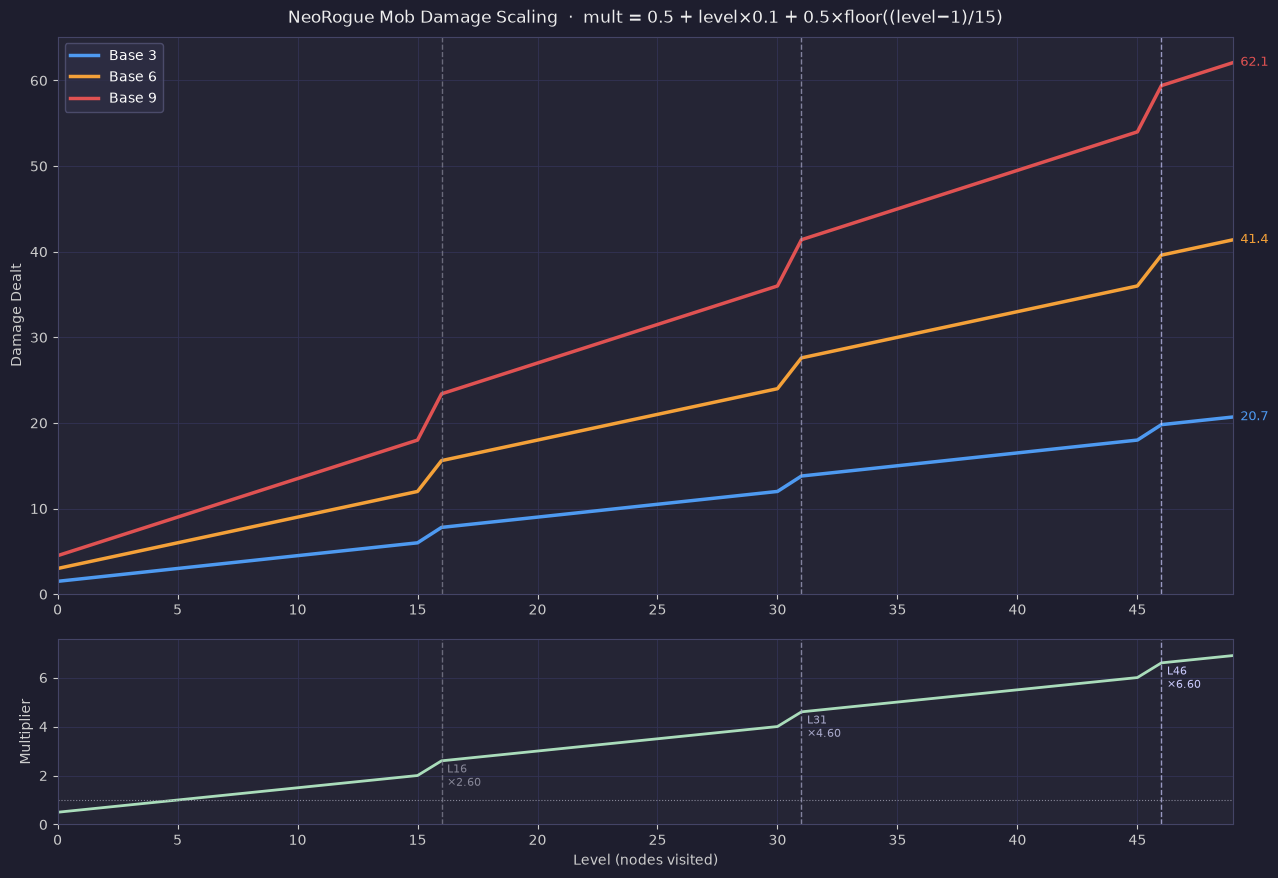

In [16]:
MAX_LEVEL = 49

fig, (ax_dmg, ax_mult) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#1e1e2e')
for ax in (ax_dmg, ax_mult):
    ax.set_facecolor('#252535')
    ax.tick_params(colors='#cccccc')
    ax.xaxis.label.set_color('#cccccc')
    ax.yaxis.label.set_color('#cccccc')
    ax.title.set_color('#eeeeee')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# ── Top panel: damage lines ────────────────────────────────────────────────
milestone_levels = [16, 31, 46]
milestone_colors = ['#888899', '#aaaacc', '#ccccff']

for b, c in zip(bases, colors):
    ax_dmg.plot(levels, df[f'base_{b}'], color=c, linewidth=2.5, label=f'Base {b}')
    # end-of-range label
    ax_dmg.annotate(f'{mob_damage(b, MAX_LEVEL):.1f}',
                    xy=(MAX_LEVEL, mob_damage(b, MAX_LEVEL)),
                    xytext=(5, 0), textcoords='offset points',
                    color=c, fontsize=9, va='center')

# milestone vertical lines (top panel only)
for lvl, mc in zip(milestone_levels, milestone_colors):
    ax_dmg.axvline(lvl, color=mc, linewidth=1.0, linestyle='--', alpha=0.7)

ax_dmg.set_title('NeoRogue Mob Damage Scaling  ·  mult = 0.5 + level×0.1 + 0.5×floor((level−1)/15)',
                 fontsize=12, pad=10)
ax_dmg.set_ylabel('Damage Dealt', fontsize=10)
ax_dmg.set_xlim(0, MAX_LEVEL)
ax_dmg.set_ylim(0)
ax_dmg.grid(True, color='#333355', linewidth=0.6)
ax_dmg.legend(facecolor='#2e2e45', edgecolor='#555577', labelcolor='white', fontsize=10)
ax_dmg.xaxis.set_major_locator(ticker.MultipleLocator(5))

# ── Bottom panel: multiplier curve ────────────────────────────────────────
ax_mult.plot(levels, df['mult'], color='#aaddbb', linewidth=2, label='Multiplier')
ax_mult.axhline(1.0, color='#888899', linewidth=0.8, linestyle=':')
for lvl, mc in zip(milestone_levels, milestone_colors):
    ax_mult.axvline(lvl, color=mc, linewidth=1.0, linestyle='--', alpha=0.7)
    ax_mult.annotate(f'L{lvl}\n×{multiplier(lvl):.2f}',
                     xy=(lvl, multiplier(lvl)),
                     xytext=(4, -18), textcoords='offset points',
                     color=mc, fontsize=8)

ax_mult.set_ylabel('Multiplier', fontsize=10)
ax_mult.set_xlabel('Level (nodes visited)', fontsize=10)
ax_mult.set_xlim(0, MAX_LEVEL)
ax_mult.set_ylim(0, multiplier(MAX_LEVEL) * 1.1)
ax_mult.grid(True, color='#333355', linewidth=0.6)
ax_mult.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout(pad=1.5)
plt.show()

## 5. Key Milestone Summary Table

In [17]:
milestone_rows = [0, 5, 10, 15, 16, 20, 25, 30, 31, 35, 40, 45, 46]
summary = pd.DataFrame({
    'Level':      milestone_rows,
    'Multiplier': [f'{multiplier(l):.2f}×' for l in milestone_rows],
    'Base 3':     [f'{mob_damage(3, l):.2f}' for l in milestone_rows],
    'Base 6':     [f'{mob_damage(6, l):.2f}' for l in milestone_rows],
    'Base 9':     [f'{mob_damage(9, l):.2f}' for l in milestone_rows],
})
print(summary.to_string(index=False))

 Level Multiplier Base 3 Base 6 Base 9
     0      0.50×   1.50   3.00   4.50
     5      1.00×   3.00   6.00   9.00
    10      1.50×   4.50   9.00  13.50
    15      2.00×   6.00  12.00  18.00
    16      2.60×   7.80  15.60  23.40
    20      3.00×   9.00  18.00  27.00
    25      3.50×  10.50  21.00  31.50
    30      4.00×  12.00  24.00  36.00
    31      4.60×  13.80  27.60  41.40
    35      5.00×  15.00  30.00  45.00
    40      5.50×  16.50  33.00  49.50
    45      6.00×  18.00  36.00  54.00
    46      6.60×  19.80  39.60  59.40
